# Análisis de eutrofización sistema de monitoreo nacioanl de aguas continentales

Este cuaderno realiza el procesamiento de la base de datos `BDD FSQ 2011-2025` para calcular un indicador de eutrofización (Índice de Estado Trófico de Carlson). Se utilizan los parámetros de clorofila a y fósforo total para calcular el TSI y se obtiene un promedio anual por sistema.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ruta del archivo Excel cargado
file_path = './01 Anexo I. BDD Monitoreo Humedales 2011-2025 CA_V3.xlsx'

# Leer la hoja de datos
all_df = pd.read_excel(file_path, sheet_name='BDD FSQ 2011-2025', dtype=str)
print('Filas totales:', all_df.shape)


Filas totales: (10388, 28)


In [18]:
# =========================
# Preparación del dataframe
# =========================
df = all_df.copy()

# -------------------------
# Función para convertir valores numéricos
# -------------------------
def parse_val(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().replace(',', '.')
    for s in ['<', '>', '≤', '≥', '<=', '>=']:
        v = v.replace(s, '')
    try:
        return float(v)
    except:
        return np.nan

# -------------------------
# Conversión de unidades
# -------------------------
def convert_to_ugL(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    unit = unit.lower()
    if 'mg' in unit:
        return value * 1000
    return value

def convert_to_mgL(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    unit = unit.lower()
    if 'µg' in unit or 'ug' in unit:
        return value / 1000
    return value

# -------------------------
# Fechas
# -------------------------
df['date'] = pd.to_datetime(df['MUEST_Fecha'], errors='coerce')
df['year'] = df['date'].dt.year

# =========================
# Clorofila a
# =========================
chl = df[df['PAR_Nombre'].str.contains('Clorofila', case=False, na=False)].copy()
chl['value'] = chl['MED_Valor'].apply(parse_val)
chl['ugL']   = chl.apply(lambda r: convert_to_ugL(r['value'], r['PAR_Unidad']), axis=1)
chl = chl[chl['ugL'] > 0]

chl['TSI_Clorofila'] = 9.81 * np.log(chl['ugL']) + 30.6
chl_group = (
    chl
    .groupby(['SISTEMA', 'year'])['TSI_Clorofila']
    .mean()
    .reset_index()
)

# =========================
# Fósforo total
# =========================
pt = df[df['PAR_Nombre'].str.contains('Fosforo Total', case=False, na=False)].copy()
pt['value'] = pt['MED_Valor'].apply(parse_val)
pt['ugL']   = pt.apply(lambda r: convert_to_ugL(r['value'], r['PAR_Unidad']), axis=1)
pt = pt[pt['ugL'] > 0]

pt['TSI_Fosforo'] = 14.42 * np.log(pt['ugL']) + 4.15
pt['Fósforo_mgL'] = pt['ugL'] / 1000

pt_group = (
    pt
    .groupby(['SISTEMA', 'year'])
    .agg(
        TSI_Fosforo=('TSI_Fosforo', 'mean'),
        Fósforo_mgL=('Fósforo_mgL', 'mean')
    )
    .reset_index()
)

# =========================
# Nitrógeno total
# =========================
nt = df[df['PAR_Nombre'].str.contains('Nitrogeno Total', case=False, na=False)].copy()
nt['value'] = nt['MED_Valor'].apply(parse_val)
nt['Nitrógeno_mgL'] = nt.apply(lambda r: convert_to_mgL(r['value'], r['PAR_Unidad']), axis=1)
nt = nt[nt['Nitrógeno_mgL'] > 0]

nt_group = (
    nt
    .groupby(['SISTEMA', 'year'])['Nitrógeno_mgL']
    .mean()
    .reset_index()
)

# =========================
# Integración final
# =========================
results_df = (
    chl_group
    .merge(pt_group, on=['SISTEMA', 'year'], how='outer')
    .merge(nt_group, on=['SISTEMA', 'year'], how='outer')
)

# TSI promedio
results_df['TSI_Promedio'] = results_df[['TSI_Clorofila', 'TSI_Fosforo']].mean(axis=1)

# Categoría trófica
def trophic_category(tsi):
    if pd.isna(tsi):
        return None
    elif tsi < 30:
        return 'Ultraoligotrófico'
    elif tsi < 44:
        return 'Oligotrófico'
    elif tsi < 54:
        return 'Mesotrófico'
    elif tsi < 74:
        return 'Eutrófico'
    else:
        return 'Hipereutrófico'

results_df['Categoria'] = results_df['TSI_Promedio'].apply(trophic_category)

# Relación N:P (masa)
results_df['Relación_N_P_masa'] = (
    results_df['Nitrógeno_mgL'] / results_df['Fósforo_mgL']
)

# Orden final
results_df = (
    results_df
    .rename(columns={'year': 'Año'})
    .sort_values(['SISTEMA', 'Año'])
    .reset_index(drop=True)
)

results_df


,SISTEMA,Año,TSI_Clorofila,TSI_Fosforo,Fósforo_mgL,Nitrógeno_mgL,TSI_Promedio,Categoria,Relación_N_P_masa
0,Boca Maule (Coronel),2024,53.188360,NaN,NaN,0.650,53.188360,Mesotrófico,NaN
1,Boca Maule (Coronel),2025,53.188360,NaN,NaN,1.100,53.188360,Mesotrófico,NaN
2,El Peral,2013,NaN,87.597060,0.3260,2.727,87.597060,Hipereutrófico,8.365031
3,Estero Cartagena,2015,80.648619,NaN,NaN,NaN,80.648619,Hipereutrófico,NaN
4,Estero Casablanca,2013,NaN,78.871319,0.1780,0.311,78.871319,Hipereutrófico,1.747191
...,...,...,...,...,...,...,...,...,...
348,Río Rapel,2025,53.188360,NaN,NaN,2.680,53.188360,Mesotrófico,NaN
349,Río Toltén,2024,53.188360,NaN,NaN,0.425,53.188360,Mesotrófico,NaN
350,Río Toltén,2025,53.188360,NaN,NaN,0.505,53.188360,Mesotrófico,NaN
351,San Sebastian (F),2013,NaN,82.218088,0.2245,0.646,82.218088,Hipereutrófico,2.877506


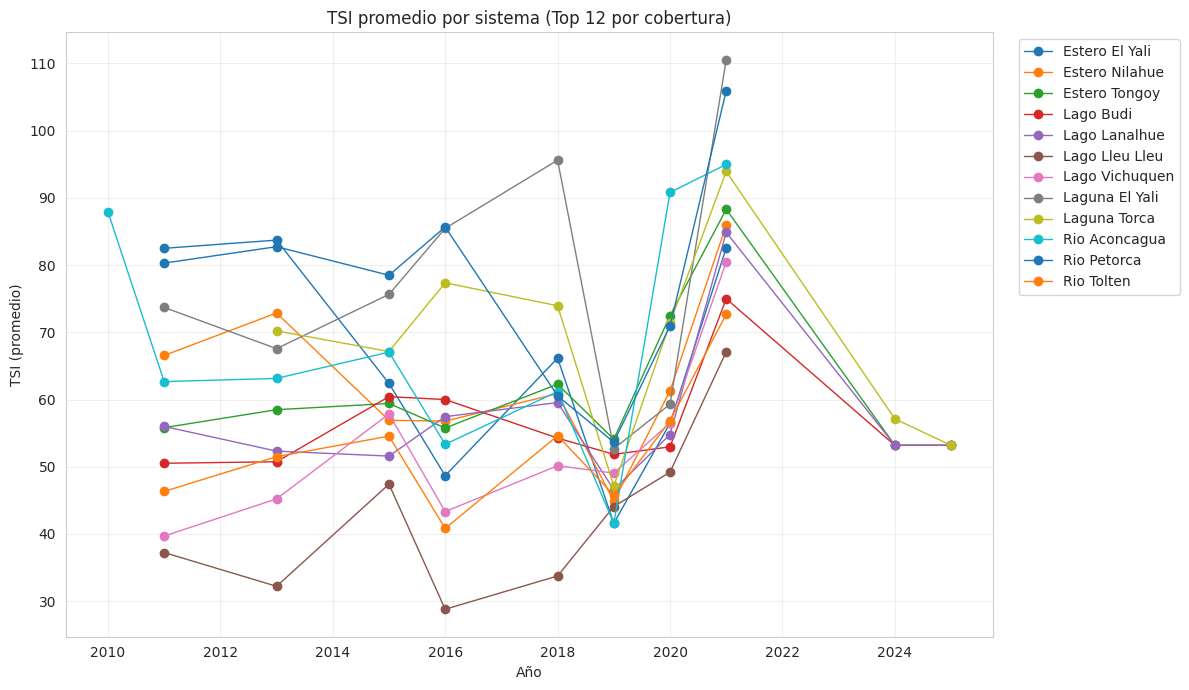

In [19]:
import matplotlib.pyplot as plt

plot_df = results_df.copy()
plot_df["Año"] = pd.to_numeric(plot_df["Año"], errors="coerce")
plot_df = plot_df.dropna(subset=["Año", "TSI_Promedio"]).sort_values(["SISTEMA", "Año"])

# Top N por cobertura temporal
N = 12
top_sistemas = (
    plot_df.groupby("SISTEMA")["Año"]
    .nunique()
    .sort_values(ascending=False)
    .head(N)
    .index
)

plot_df_top = plot_df[plot_df["SISTEMA"].isin(top_sistemas)]

plt.figure(figsize=(12, 7))
for sistema, g in plot_df_top.groupby("SISTEMA"):
    plt.plot(g["Año"], g["TSI_Promedio"], marker="o", linewidth=1, label=sistema)

plt.xlabel("Año")
plt.ylabel("TSI (promedio)")
plt.title(f"TSI promedio por sistema (Top {N} por cobertura)")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
